In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


In [ ]:
class_names = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

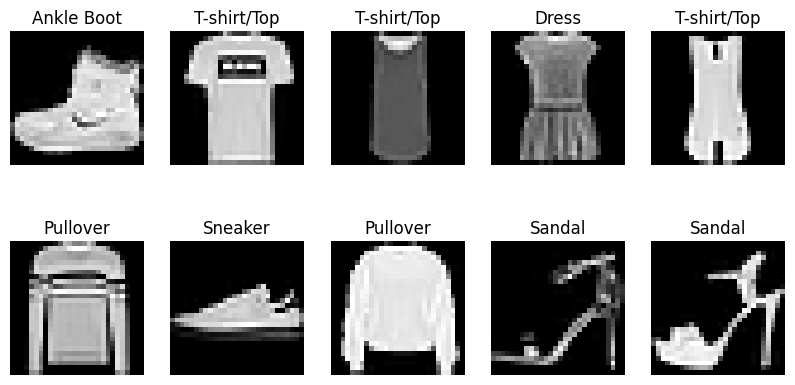

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7726 - loss: 0.6328 - val_accuracy: 0.8503 - val_loss: 0.4077
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8471 - loss: 0.4223 - val_accuracy: 0.8746 - val_loss: 0.3452
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8676 - loss: 0.3639 - val_accuracy: 0.8822 - val_loss: 0.3163
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8813 - loss: 0.3278 - val_accuracy: 0.8951 - val_loss: 0.2836
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8908 - loss: 0.3012 - val_accuracy: 0.8981 - val_loss: 0.2732
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8969 - loss: 0.2827 - val_accuracy: 0.9053 - val_loss: 0.2539
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9042 - loss: 0.2620 - val_accuracy: 0.9062 - val_loss: 0.2549
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9094 - loss: 0.2469 - val_accuracy: 0.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9034 - loss: 0.2612
Test Loss: 0.261213481426239
Test Accuracy: 0.9034000039100647


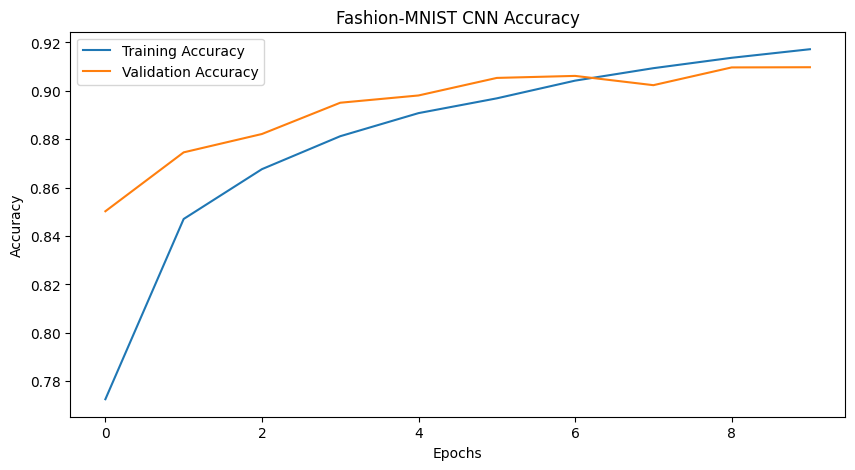

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Fashion-MNIST CNN Accuracy')
plt.legend()

plt.show()

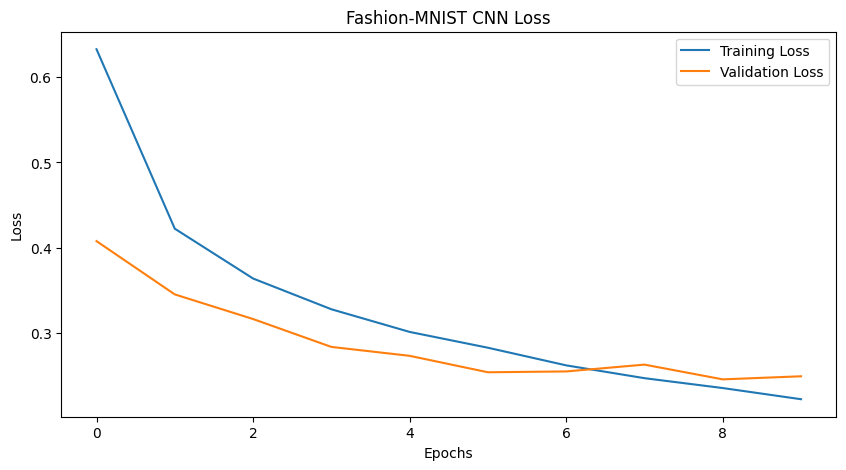

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Fashion-MNIST CNN Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


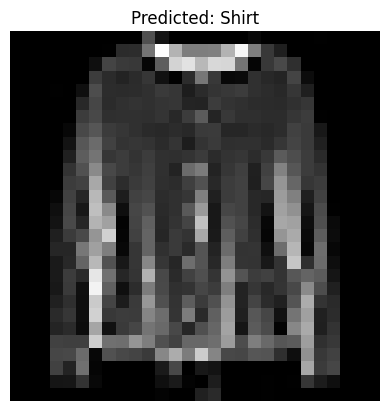

Predicted Class: Shirt
Confidence: 41.70827 %


In [ ]:
sample = X_test[25]

prediction = model.predict(
    sample.reshape(1,28,28,1)
)

predicted_class = np.argmax(prediction)

plt.imshow(sample.reshape(28,28), cmap='gray')
plt.title(
    f"Predicted: {class_names[predicted_class]}"
)
plt.axis('off')
plt.show()

print("Predicted Class:",
      class_names[predicted_class])

print("Confidence:",
      np.max(prediction)*100, "%")

Saving WhatsApp Image 2026-06-04 at 10.30.05 AM.jpeg to WhatsApp Image 2026-06-04 at 10.30.05 AM.jpeg


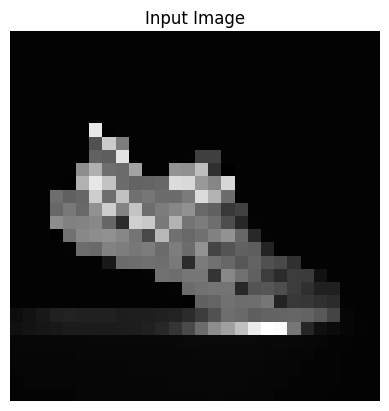

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Item: Bag
Confidence: 36.483017 %


In [ ]:
from google.colab import files
import cv2

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Resize to Fashion-MNIST size
img = cv2.resize(img, (28,28))

# Invert if needed
img = 255 - img

# Normalize
img = img / 255.0

plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

img = img.reshape(1,28,28,1)

prediction = model.predict(img)

predicted_class = np.argmax(prediction)

print("Predicted Item:",
      class_names[predicted_class])

print("Confidence:",
      np.max(prediction)*100, "%")